<a href="https://colab.research.google.com/github/fdavenport/CIVE480A-Fall26/blob/main/Lab1_Greenhouse_Gases_and_Radiation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CIVE 480A6: Climate Change Risks and Impacts
### Greenhouse Gases and Earth's Radiation

In this lab, we will use Python to explore the greenhouse gases that drive climate change and the physics that connects them to Earth's temperature. The lab has three parts:

1. **Greenhouse gas concentrations** – read in real atmospheric measurements of carbon dioxide, methane, and nitrous oxide, and plot how their concentrations have changed over time.
2. **Sources of greenhouse gas emissions** – analyze where greenhouse gas emissions come from, by country and by economic sector.
3. **Earth's electromagnetic radiation** – use the Stefan–Boltzmann law to relate the energy radiated by a surface to its temperature, and Wien's law to find the wavelengths of light that Earth and the Sun emit.

Each part starts with a guided walk-through and then has problems and discussion questions for you to complete. Some code cells are complete and ready to run. Others contain code you need to change (look for a comment that starts with `# TO DO`) or a blank space for your answer. Watch for the **STOP** cells – pause there and check in before moving on.

### Setting up

First we import two Python libraries we used previously: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

The data files for this lab live in the `data/` folder of the course GitHub repository. The line below stores the web address of that folder in a variable so we can reuse it each time we read a file.

In [2]:
data_url = "https://raw.githubusercontent.com/fdavenport/CIVE480A-Fall26/main/data/"

# Part 1: Greenhouse gas concentrations

In the first problem, you will analyze measured greenhouse gas concentrations: 
* **Carbon dioxide (CO$_2$)** – monthly values measured at Mauna Loa Observatory in Hawaiʻi in parts per million (ppm). 
* **Methane (CH$_4$)** – monthly global average from National Oceanic Atmospheric Administartion (NOAA) measurements, in parts per billion (ppb).
* **Nitrous oxide (N$_2$O)** – monthly global values from NOAA measurements, in parts per billion (ppb). 

### Reading in a data file

The data is stored in **CSV files** (comma-separated values). A CSV file contains a table of information, a lot like an Excel spreadsheet. Each row is on its own line and the columns are separated by commas. We will use the `pandas` python library to read and analyze the data. You can read in the csv files with the function `pd.read_csv()`.

In [4]:
import pandas as pd

In [5]:
co2 = pd.read_csv(data_url + "co2_mm_mlo.csv")
ch4 = pd.read_csv(data_url + "ch4_mm_gl.csv")
n2o = pd.read_csv(data_url + "n2o_mm_gl.csv")

The table that pandas creates is called a **DataFrame**. The next few cells will walk you through reading or selecting values from within the data frame: 

In [11]:
# print out the data frame (python will hide the middle rows)
co2

,year,month,average_ppm
0,1958,3,315.71
1,1958,4,317.45
2,1958,5,317.51
3,1958,6,317.27
4,1958,7,315.87
...,...,...,...
816,2026,3,430.15
817,2026,4,431.12
818,2026,5,432.34
819,2026,6,431.44


In [6]:
# head() prints the first rows of the data frame (5 by default)
co2.head()

,year,month,average_ppm
0,1958,3,315.71
1,1958,4,317.45
2,1958,5,317.51
3,1958,6,317.27
4,1958,7,315.87


In [7]:
# you can also specify a different number of rows to print
co2.head(n=10)

,year,month,average_ppm
0,1958,3,315.71
1,1958,4,317.45
2,1958,5,317.51
3,1958,6,317.27
4,1958,7,315.87
5,1958,8,314.93
6,1958,9,313.21
7,1958,10,312.42
8,1958,11,313.33
9,1958,12,314.67


In [8]:
# tail() prints the last rows of the data frame
co2.tail()

,year,month,average_ppm
816,2026,3,430.15
817,2026,4,431.12
818,2026,5,432.34
819,2026,6,431.44
820,2026,7,429.12


In [ ]:
# select a column using square brackets and the column name
co2["average_ppm"]

In [12]:
# print minimum and maximum values: 
print("minimum:", co2["average_ppm"].min())
print("maximum:", co2["average_ppm"].max())

minimum: 312.42
maximum: 432.34


In [18]:
# select a row (in this case, the first row)
co2.iloc[0] # "iloc" stands for integer location

year           1958.00
month             3.00
average_ppm     315.71
Name: 0, dtype: float64

In [19]:
# select a range of rows:
co2.iloc[0:10]

,year,month,average_ppm
0,1958,3,315.71
1,1958,4,317.45
2,1958,5,317.51
3,1958,6,317.27
4,1958,7,315.87
5,1958,8,314.93
6,1958,9,313.21
7,1958,10,312.42
8,1958,11,313.33
9,1958,12,314.67


### **1a)** Adding a date column

For plotting it is handy to combine the separate `year` and `month` columns into a single **date**. `pd.to_datetime()` builds real calendar dates from a table of date parts. We give it the `year` and `month` columns plus a `day` (we use `1`, the first of each month). The new column holds values like `1958-03-01`, and matplotlib knows how to put dates on an axis when plotting.

In [21]:
co2["date"] = pd.to_datetime(co2[["year", "month"]].assign(day=1))
co2.head() # print out the data frame to check how it looks

,year,month,average_ppm,date
0,1958,3,315.71,1958-03-01
1,1958,4,317.45,1958-04-01
2,1958,5,317.51,1958-05-01
3,1958,6,317.27,1958-06-01
4,1958,7,315.87,1958-07-01


In [ ]:
# TO DO - add date columns for the methane and nitrous oxide data frames


### **1b)** Plotting the time series

Now you will make time series plots of the data. We will create a figure with three separate panels with the `plt.subplots()` command. `plt.subplots(1, 3, ...)` makes a figure with three sub "axes" arranged in one row and three columns.`axes[0]` is the first panel, `axes[1]` the second, `axes[2]` the third.

The left panel is filled in for CO$_2$. Fill in the next two panels for methane and nitrous oxide.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(co2["date"], co2["average_ppm"], color="black")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("CO$_2$ concentration (ppm)")
axes[0].set_title("Carbon dioxide")

# TO DO: fill in axes[1] for methane (ch4) and axes[2] for nitrous oxide (n2o)



plt.tight_layout()
plt.show()

### **1c)** – when did CO$_2$ first pass 350 and 400 ppm?

Now you will determine when CO$_2$ first past different thresholds. 
The expression `co2["average_ppm"] > 350` gives a `True`/`False` value for every row: 

In [22]:
co2["average_ppm"] > 350

0      False
1      False
2      False
3      False
4      False
       ...  
816     True
817     True
818     True
819     True
820     True
Name: average_ppm, Length: 821, dtype: bool

You can use this expression to subset the original data frame to only contain rows where this condition is true. Because the data frame is ordered by date, the first row of the table will tell use the first date when this threshold was crossed: 

In [29]:
print("first month above 350ppm:", co2[co2["average_ppm"] > 350]["date"].iloc[0])



first month above 350ppm: 1986-05-01 00:00:00


In [ ]:
# TO DO: calculate when CO2 first passed 400 ppm


### **1d)** How much have GHG concentrations increased compared to pre-industrial levels? 

Before widespread fossil fuel use, atmospheric concentrations were roughly:

| gas | pre-industrial concentration |
|---|---|
| CO$_2$ | 278 ppm |
| CH$_4$ | 722 ppb |
| N$_2$O | 270 ppb |

For each gas, calculate how many times higher concentrations are in the most recent values compared to preindustrial conditions.

In [ ]:
## TO DO: calculate increase in CO2

In [ ]:
## TO DO: calculate increase in CH4

In [ ]:
## TO DO: calculate increase in N2O

Which gas has increased the most, in proportional terms?

*add answer here* 

### **STOP** and let me know you are at this point

# Part 2: Sources of greenhouse gas emissions

In this section, you will analyze sources of greenhouse gas emissions broken down by country, state, and economic sector over time. Greenhouse gas emissions are given as CO2 equivalent. These "equivalent" units account for the fact that different gases absorb infrared radiation in different amounts, so have different effects on global temperature change. 


### Global emissions over time

Start with the country file and look at the first few rows.

In [30]:
emissions = pd.read_csv(data_url + "ghg_emissions_country.csv")
emissions.head()

,Country,Code,Year,annual_ghg_emissions
0,Afghanistan,AFG,1850,7544802.5
1,Afghanistan,AFG,1851,7608335.5
2,Afghanistan,AFG,1852,7668358.0
3,Afghanistan,AFG,1853,7727762.5
4,Afghanistan,AFG,1854,7785914.5


The columns are `Country` (a country, region, or "World"), `Code`, `Year`, and `annual_ghg_emissions` (the emissions value).

To pull out just the world total, we **filter** the rows: `emissions["Country"] == "World"` produces `True`/`False` for every row, and putting that inside `emissions[ ... ]` keeps only the `True` rows.

In [31]:
# keep only the rows where Country is "World"
world = emissions[emissions["Country"] == "World"]
world.head()

,Country,Code,Year,annual_ghg_emissions
37450,World,OWID_WRL,1850,4.293311e+09
37451,World,OWID_WRL,1851,4.409168e+09
37452,World,OWID_WRL,1852,4.523711e+09
37453,World,OWID_WRL,1853,4.561398e+09
37454,World,OWID_WRL,1854,4.653988e+09


The emissions values are in tonnes per year. Dividing by 1e9 (one billion) converts them to **billion tonnes** (gigatonnes) of CO$_2$-equivalent, which is easier to read.

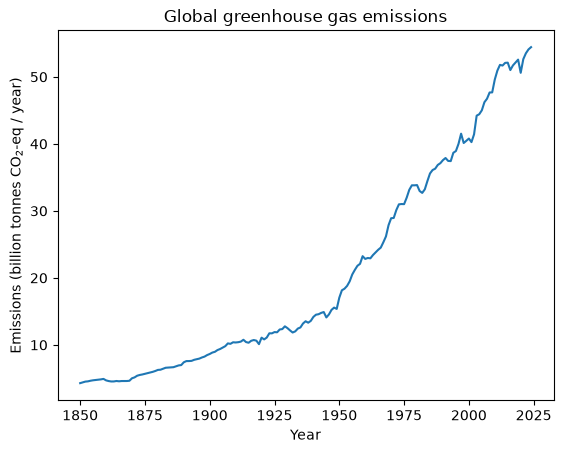

In [32]:
plt.plot(world["Year"], world["annual_ghg_emissions"] / 1e9)
plt.xlabel("Year")
plt.ylabel("Emissions (billion tonnes CO$_2$-eq / year)")
plt.title("Global greenhouse gas emissions")
plt.show()

### Comparing countries

We can filter to a single country the same way. Here is the United States:

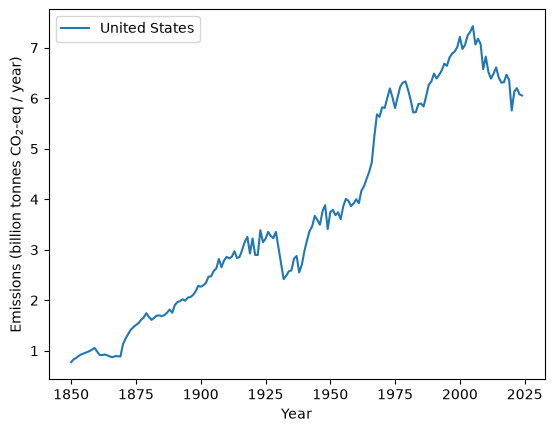

In [33]:
usa = emissions[emissions["Country"] == "United States"]

plt.plot(usa["Year"], usa["annual_ghg_emissions"] / 1e9, label="United States")
plt.xlabel("Year")
plt.ylabel("Emissions (billion tonnes CO$_2$-eq / year)")
plt.legend()
plt.show()

### Exercise 2.1 – add more countries

Modify the code below so it also plots **China** and **India** on the same axes. Add a `plt.plot(...)` line for each, and give each one a `label=` so the legend can tell them apart.

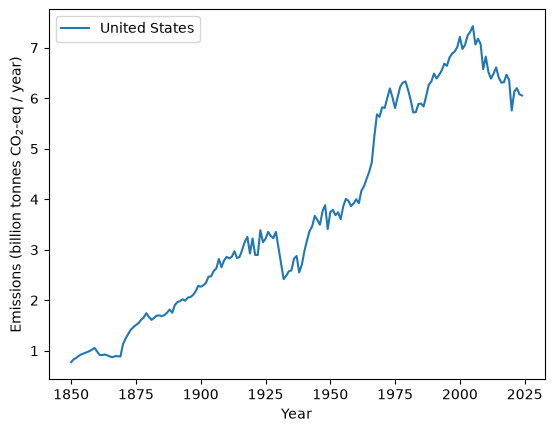

In [34]:
usa = emissions[emissions["Country"] == "United States"]
plt.plot(usa["Year"], usa["annual_ghg_emissions"] / 1e9, label="United States")

# TO DO: filter emissions to China and to India, and add a plt.plot line for each


plt.xlabel("Year")
plt.ylabel("Emissions (billion tonnes CO$_2$-eq / year)")
plt.legend()
plt.show()

### Problem 2.2 – emissions in the most recent year

Print the emissions of the United States, China, and India in the most recent year, 2024. Then look at 1990. Which country emitted the most in 1990, and which emits the most now?

Hint: to get one country in one year, filter on both conditions, e.g. `china[china["Year"] == 2024]`.

In [35]:
# add your code here


### The biggest emitters

So far we have picked countries by name. To find the **largest emitters** we can sort the table instead. First we need to keep only individual countries: the file also has rows for regions and groups like `World`, `Asia`, or `High-income countries`. Those aggregate rows have a `Code` that starts with `OWID`, while real countries have an ordinary three-letter code, so we filter the aggregates out.

In [ ]:
countries_only = emissions[emissions["Code"].notna() & ~emissions["Code"].str.startswith("OWID", na=False)]

# keep one year, then sort to get the 20 largest emitters
year_2023 = countries_only[countries_only["Year"] == 2023]
top20 = year_2023.nlargest(20, "annual_ghg_emissions")
top20[["Country", "annual_ghg_emissions"]]

A horizontal bar chart (`plt.barh`) is a good way to show a ranked list.

In [ ]:
plt.barh(top20["Country"], top20["annual_ghg_emissions"] / 1e9)
plt.xlabel("Emissions in 2023 (billion tonnes CO$_2$-eq)")
plt.title("Top 20 greenhouse gas emitters, 2023")
plt.gca().invert_yaxis()   # largest at the top
plt.show()

### Cumulative emissions

The atmosphere responds to the **total** amount of CO$_2$-equivalent added over time, not just one year's emissions. **Cumulative emissions** add up every year of a country's record. `groupby("Country")` collects all the rows for each country and `.sum()` adds their emissions together.

In [ ]:
cumulative = countries_only.groupby("Country")["annual_ghg_emissions"].sum()

# the United States, as an example
print("US cumulative emissions:", round(cumulative["United States"] / 1e9), "billion tonnes CO2-eq")

### Exercise 2.3 – the largest cumulative emitters

Using the `cumulative` totals, print the **20 countries with the largest cumulative emissions** and make a horizontal bar chart of them. `cumulative.sort_values(ascending=False).head(20)` gives you the top 20. Compare this ranking with the single-year top 20 above – which countries move up, and which move down?

In [ ]:
# TO DO: sort `cumulative` from largest to smallest and keep the top 20


# TO DO: make a horizontal bar chart of the top 20 cumulative emitters (divide by 1e9 for Gt)


### Where do emissions come from? U.S. emissions by sector

The country file tells us *who* emits, but not *what activities* are responsible. For that we use the more detailed U.S. EPA file.

In [ ]:
us_emissions = pd.read_csv(data_url + "ghg_emissions_state_sector.csv")
us_emissions.head()

This table has many descriptive columns and then one column per year, named `Y1990`, `Y1991`, …, `Y2022` (this "wide" layout has each year in its own column). The columns we will group by are:

* `geo_ref` – the U.S. state (two-letter abbreviation)
* `econ_sector` – the economic sector (Transportation, Electric Power Industry, etc.)
* `ghg_category` – the gas (CO2, CH4, N2O, …)

In [ ]:
print(us_emissions.columns.tolist())
print("sectors:", us_emissions["econ_sector"].unique())
print("gases:", us_emissions["ghg_category"].unique())

We will focus on **Colorado**. First filter to the rows where `geo_ref` is `"CO"`.

Each sector is split across many rows (one per activity and gas), so to get a sector total we use `.groupby()`: `colorado.groupby("econ_sector")["Y2022"].sum()` adds up the 2022 column within each economic sector.

In [ ]:
colorado = us_emissions[us_emissions["geo_ref"] == "CO"]

# add up 2022 emissions within each economic sector
colorado_by_sector = colorado.groupby("econ_sector")["Y2022"].sum()
colorado_by_sector

A **bar chart** is the natural way to compare categories. `plt.bar()` takes the category names and the values. `.index` gives the sector names and `.values` gives the numbers.

In [ ]:
plt.bar(colorado_by_sector.index, colorado_by_sector.values)
plt.ylabel("Emissions in 2022 (Tg CO$_2$-eq)")
plt.title("Colorado greenhouse gas emissions by sector, 2022")
plt.xticks(rotation=45, ha="right")
plt.show()

### Exercise 2.4 – break down by gas instead of sector

Copy the two cells above, but group by `"ghg_category"` instead of `"econ_sector"` to see which **gases** make up Colorado's emissions. Make a bar chart of the result.

In [ ]:
# TO DO: group Colorado emissions by ghg_category for Y2022, then make a bar chart


### Exercise 2.5 – which sectors have passed their peak?

A sector's emissions can be **falling** even while they are still higher than they were in 1990. To see this, compare each sector's 2022 value with its **highest year on record**, not just with 1990.

Add up emissions for the **whole United States** (all states together) in each economic sector, for every year from 1990 to 2022. Then, for each sector, find the peak value across all those years with `.max(axis=1)` and the year it happened with `.idxmax(axis=1)` (`axis=1` means "work across the year columns, one sector at a time").

Add a column for how far 2022 sits below that peak, and sort by it. Which sectors are now well below their all-time high? Which are still at or near it? For which sectors would comparing 2022 with 1990 alone give a misleading picture of the recent trend?

In [ ]:
year_cols = [f"Y{y}" for y in range(1990, 2023)]
us_by_sector = us_emissions.groupby("econ_sector")[year_cols].sum()

summary = pd.DataFrame({
    "peak_year": us_by_sector.idxmax(axis=1),
    "peak_value": us_by_sector.max(axis=1),
    "value_1990": us_by_sector["Y1990"],
    "value_2022": us_by_sector["Y2022"],
})

# TO DO: add a column summary["below_peak"] = value_2022 - peak_value
#        (0 means 2022 is the peak; a more negative number means further past the peak)


# TO DO: sort `summary` by "below_peak" and display it


### Problem 2.6 – pick another state

Repeat the sector bar chart for a different state of your choice (use its two-letter abbreviation in place of `"CO"`). Name one way its emissions profile differs from Colorado's.

In [ ]:
# TO DO: change "CO" to another state abbreviation and remake the sector bar chart


### Discussion 2.7

**a)** Global emissions have risen almost every decade (first figure of Part 2). Compare that with the CO$_2$ concentration curve from Part 1. For the atmospheric concentration to stop rising, what would have to happen to emissions – is it enough for them to stop *increasing*?

**b)** Choose **three** economic sectors to research: **Electric Power Industry** and **Agriculture**, plus **one more** from the list that interests you (for example Transportation, Industry, Commercial, or Residential). For each of the three, describe the main activities that release greenhouse gases and which gas or gases dominate (CO$_2$, CH$_4$, N$_2$O). The EPA's [overview of greenhouse gas emissions](https://www.epa.gov/ghgemissions/sources-greenhouse-gas-emissions) by sector is a good starting point.

*your answer here*

### **STOP**. Wait here and raise your hand to let me know you are at this point.

# Part 3: Earth's electromagnetic radiation

As we covered in class, every object emits radiation. The amount of radiation emitted depends on temperatureand is given by the Stefan-Boltzmann Law: 

$$E = \epsilon \sigma \, T^4$$

* $E$ = power radiated per unit area \[W/m$^2$]
* $\epsilon$ = emissivity
* $\sigma = 5.67 \times 10^{-8}$ W/m$^2$K$^4$ is the Stefan–Boltzmann constant
* $T$ = temperature in K

Using this equation, we can calculate the radiation emitted by an object with a temperature of 300K (around the temperature of Earth). In Python, `5.67e-8` means $5.67 \times 10^{-8}$, and `**` is the exponent operator, so `T**4` is $T^4$.

In [36]:
sigma = 5.67e-8   # Stefan-Boltzmann constant, W / m^2 / K^4

print("Energy radiated by 300K object:", sigma * 300**4,  "W/m^2")

Energy radiated by 300K object: 459.27 W/m^2


### **3** - Calculating temperature from measured radiation

Some satellites can measure the infrared radiation emitted from earth. Using the Stefan-Boltzmann law (and other equations), these measurements can be converted back to temperature. 

<img src="https://raw.githubusercontent.com/fdavenport/CIVE480A-Fall26/main/img/modis.png">


The actual measurements and calculations done by satellites are quite complicated. Here, we will assume you have a special hypothetical device that can measure the total amount of radiation emitted from the earth's surface. You have measurements from three different locations: 

| location | measured radiation (W/m$^2$) |
|---|---|
| A – tropical ocean | 470 |
| B – desert at midday | 630 |
| C – Antarctic plateau in winter | 130 |

**3a)** Write a function `temperature_from_radiation()` and use it to calculate temperature at each of the three points, in kelvin.

In [ ]:
def temperature_from_radiation(E):
    """Temperature (K) of a surface that radiates E watts per square meter."""
    # TO DO: replace the line below with code to calculate temperature based on radiated power
    
    return T


**3b)** Convert each to $^\circ$C (K = $^\circ$C + 273). Do the values look reasonable for those places?


In [ ]:
# add code here

**3c)** The instrument's calibration at point A is uncertain by about $\pm15$ W/m$^2$. Recompute point A's temperature for 455 and 485 W/m$^2$. How many kelvin does that 30 W/m$^2$ spread correspond to?


In [ ]:
# add code here


In [ ]:
# add your code here


*your answer to (b) and (d) here*

**3d)** Based on the Stefan–Boltzmann law, explain why a given fractional error in the measured radiation produces a much smaller fractional error in temperature.

### Exporting this notebook as an HTML file

When you're done, convert your work to an HTML file using the code below. The HTML file will preserve your code, text, and output as it appears. You can then submit the HTML file on Canvas.

Before running it, make sure you have run all of the cells you want included so their output shows up. The easiest way is to select "Restart session and run all" under the Runtime dropdown menu at the top of Colab. When it finishes in Colab, the HTML file will download automatically.

In [ ]:
# 1. make sure this matches your notebook's filename (shown at the top-left of the Colab window)
notebook_filename = "Lab1_Greenhouse_Gases_and_Radiation.ipynb"

# 2. if running in Google Colab, the .ipynb file is not on the runtime's disk, so we
#    grab the current notebook from Colab and save it before converting
try:
    import json
    from google.colab import _message
    notebook_json = _message.blocking_request("get_ipynb", request="", timeout_sec=60)["ipynb"]
    with open(notebook_filename, "w") as f:
        json.dump(notebook_json, f)
    in_colab = True
except ImportError:
    in_colab = False

# 3. convert the notebook to an HTML file
!jupyter nbconvert --to html "{notebook_filename}"

# 4. if running in Google Colab, automatically download the HTML file
if in_colab:
    from google.colab import files
    files.download(notebook_filename.replace(".ipynb", ".html"))